# Spillover network features

- builds daily yield-curve connectedness features (Diebold-Yilmaz) for the forecasting models
- output: data/generated/spillover_features.csv, plus the lag-selection cutoff date
- run before final.ipynb and final2.ipynb
- concepts explained in spillover_explained.md

In [1]:
from statsmodels.tsa.api import VAR
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/FRB_H15.csv").dropna()

#rename columns
df.rename(columns={"Series Description": "Date", "Market yield on U.S. Treasury securities at 1-month  constant maturity, quoted on investment basis": "0Y1M", "Market yield on U.S. Treasury securities at 3-month  constant maturity, quoted on investment basis": "0Y3M", "Market yield on U.S. Treasury securities at 6-month  constant maturity, quoted on investment basis": "0Y6M", "Market yield on U.S. Treasury securities at 1-year  constant maturity, quoted on investment basis": "1Y", "Market yield on U.S. Treasury securities at 2-year  constant maturity, quoted on investment basis": "2Y", "Market yield on U.S. Treasury securities at 3-year  constant maturity, quoted on investment basis": "3Y", "Market yield on U.S. Treasury securities at 5-year  constant maturity, quoted on investment basis": "5Y", "Market yield on U.S. Treasury securities at 7-year  constant maturity, quoted on investment basis": "7Y", "Market yield on U.S. Treasury securities at 10-year  constant maturity, quoted on investment basis": "10Y", "Market yield on U.S. Treasury securities at 20-year constant maturity, quoted on investment basis": "20Y", "Market yield on U.S. Treasury securities at 30-year  constant maturity, quoted on investment basis": "30Y"}, inplace=True)
df.rename(columns={"Market yield on U.S. Treasury securities at 20-year  constant maturity, quoted on investment basis": "20Y"}, inplace=True)

#make index to datetime for timeseries
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

matList = ["0Y1M", "0Y3M", "0Y6M", "1Y", "2Y", "3Y", "5Y", "7Y", "10Y", "20Y", "30Y"]

#the VAR is fit on daily CHANGES, yield levels are too persistent for a short window VAR
changes = df[matList].diff().dropna()

print("days of yield changes: ", len(changes))
changes.tail(5)

days of yield changes:  6198


,0Y1M,0Y3M,0Y6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
Date,,,,,,,,,,,
2026-05-08,-0.01,0.00,0.00,-0.01,-0.02,-0.02,-0.02,-0.03,-0.03,-0.03,-0.02
2026-05-11,0.00,0.01,0.03,0.04,0.05,0.04,0.05,0.05,0.04,0.04,0.03
2026-05-12,0.00,0.00,0.00,0.01,0.05,0.05,0.05,0.05,0.04,0.05,0.05
2026-05-13,0.00,-0.01,0.00,-0.01,-0.02,-0.01,0.00,-0.01,0.00,0.01,0.00
2026-05-14,0.01,0.00,-0.01,0.00,0.02,0.04,0.01,0.01,0.01,-0.02,-0.01


#### VAR lag selection

- computes BIC for lags 1 to 5 on the first 80% of daily changes (most recent 1500 days of that slice)
- keeps the lowest-BIC lag, fixed for the whole notebook
- writes the selection cutoff date to spillover_design_boundary.txt (final2 checks its holdout starts after this date)

In [3]:
#use only the first 80% for this design choice
lagSelectionEnd = int(0.8 * len(changes))
lagSelectionData = changes.iloc[:lagSelectionEnd]

#a recent 1500 day slice is enough to compare small lags and keeps this fast
lagSelectionData = lagSelectionData.tail(1500)

bicByLag = {}
for lag in range(1, 6):
    candidate = VAR(lagSelectionData).fit(lag, trend="c")
    bicByLag[lag] = candidate.bic

selectedLag = min(bicByLag, key=bicByLag.get)

for lag in bicByLag:
    print("lag ", lag, " BIC: ", bicByLag[lag])
print("selected VAR lag: ", selectedLag)

#save the date this choice was made through, final2 checks its holdout starts after it
lagBoundary = changes.index[lagSelectionEnd - 1]
import os
os.makedirs("../data/generated", exist_ok=True)
with open("../data/generated/spillover_design_boundary.txt", "w") as f:
    f.write(lagBoundary.isoformat())
print("lag selected using data through: ", lagBoundary.date())

C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been pro

lag  1  BIC:  -91.90660740823964
lag  2  BIC:  -91.64571114301654
lag  3  BIC:  -91.2925760906174
lag  4  BIC:  -90.92355761363667
lag  5  BIC:  -90.57736713595871
selected VAR lag:  1
lag selected using data through:  2021-05-27


#### Network functions

- generalizedFevd: builds the 11x11 matrix where entry [i][j] = share of maturity i's 10-day forecast error variance from shocks to maturity j, rows normalized to sum to 1
- summarizeNetwork: compresses one matrix into the saved features (total_connectedness, maximum_edge, average_absolute_net, and from/to/net per maturity)

In [4]:
def generalizedFevd(fittedVar, horizon):
    #moving average matrices phi0, phi1, ..., phi(horizon-1), phi0 is identity
    maMatrices = fittedVar.ma_rep(maxn=horizon - 1)
    shockCov = np.asarray(fittedVar.sigma_u)
    numSeries = shockCov.shape[0]

    shares = np.zeros((numSeries, numSeries))

    for receiver in range(numSeries):
        #total forecast error variance of the receiver over the horizon
        totalVariance = 0.0
        for phi in maMatrices:
            propagated = phi @ shockCov @ phi.T
            totalVariance = totalVariance + propagated[receiver][receiver]

        for source in range(numSeries):
            sourceVariance = shockCov[source][source]
            contribution = 0.0
            for phi in maMatrices:
                propagatedShock = phi @ shockCov
                contribution = contribution + propagatedShock[receiver][source] ** 2
            shares[receiver][source] = contribution / sourceVariance / totalVariance

    #rows dont sum to 1 before normalizing because shocks are correlated
    for receiver in range(numSeries):
        rowSum = shares[receiver].sum()
        shares[receiver] = shares[receiver] / rowSum
    return shares


def summarizeNetwork(network):
    #from others: row sum minus own share, how exposed is this maturity
    #to others: column sum minus own share, how much does it transmit
    #net = to - from, positive means net transmitter
    numSeries = len(matList)
    features = {}

    fromOthers = []
    toOthers = []
    for i in range(numSeries):
        fromOthers.append(network[i].sum() - network[i][i])
        toOthers.append(network[:, i].sum() - network[i][i])

    offDiagonalTotal = 0.0
    maxEdge = 0.0
    for i in range(numSeries):
        for j in range(numSeries):
            if i != j:
                offDiagonalTotal = offDiagonalTotal + network[i][j]
                if network[i][j] > maxEdge:
                    maxEdge = network[i][j]

    netAbsTotal = 0.0
    for i in range(numSeries):
        netAbsTotal = netAbsTotal + abs(toOthers[i] - fromOthers[i])

    features["total_connectedness"] = 100.0 * offDiagonalTotal / numSeries
    features["maximum_edge"] = 100.0 * maxEdge
    features["average_absolute_net"] = 100.0 * netAbsTotal / numSeries

    for i in range(numSeries):
        features["from_" + matList[i]] = 100.0 * fromOthers[i]
        features["to_" + matList[i]] = 100.0 * toOthers[i]
        features["net_" + matList[i]] = 100.0 * (toOthers[i] - fromOthers[i])

    return features

#### Rolling networks

- every 5th day: fit a VAR on the latest 252 daily changes, compute and summarize the network
- reindexes to all trading days with forward fill (a day's features are always from a past network)
- saves the daily table to spillover_features.csv

In [5]:
featureRows = []
lastNetwork = None
lastNetworkDate = None

window = 252
step = 5
horizon = 10

for endpoint in range(window - 1, len(changes), step):
    windowChanges = changes.iloc[endpoint - window + 1 : endpoint + 1]

    try:
        fittedVar = VAR(windowChanges).fit(selectedLag, trend="c")
        network = generalizedFevd(fittedVar, horizon)
        features = summarizeNetwork(network)
    except (np.linalg.LinAlgError, ValueError):
        #a rare numerically bad window, skip it and carry the previous network forward
        continue

    features["Date"] = changes.index[endpoint]
    featureRows.append(features)
    lastNetwork = network
    lastNetworkDate = changes.index[endpoint]

weeklyFeatures = pd.DataFrame(featureRows).set_index("Date").sort_index()

#reindex to every trading day and carry past values forward
dailyFeatures = weeklyFeatures.reindex(df.index, method="ffill").dropna()

dailyFeatures.to_csv("../data/generated/spillover_features.csv", index_label="date")
print("computed ", len(weeklyFeatures), " networks")
print("daily feature rows: ", len(dailyFeatures))
dailyFeatures.tail(5)

C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been pro

C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been pro

C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been pro

C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been pro

C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been pro

...

C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been pro

C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been pro

C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


computed  1190  networks
daily feature rows:  5947


,total_connectedness,maximum_edge,average_absolute_net,from_0Y1M,to_0Y1M,net_0Y1M,from_0Y3M,to_0Y3M,net_0Y3M,from_0Y6M,...,net_7Y,from_10Y,to_10Y,net_10Y,from_20Y,to_20Y,net_20Y,from_30Y,to_30Y,net_30Y
Date,,,,,,,,,,,,,,,,,,,,,
2026-05-08,75.845896,17.234887,12.894180,29.979139,10.813135,-19.166004,53.677652,27.261576,-26.416076,75.118502,...,16.937006,85.607132,98.803294,13.196162,83.485383,81.848403,-1.636981,81.765870,71.963194,-9.802676
2026-05-11,75.845896,17.234887,12.894180,29.979139,10.813135,-19.166004,53.677652,27.261576,-26.416076,75.118502,...,16.937006,85.607132,98.803294,13.196162,83.485383,81.848403,-1.636981,81.765870,71.963194,-9.802676
2026-05-12,75.845896,17.234887,12.894180,29.979139,10.813135,-19.166004,53.677652,27.261576,-26.416076,75.118502,...,16.937006,85.607132,98.803294,13.196162,83.485383,81.848403,-1.636981,81.765870,71.963194,-9.802676
2026-05-13,75.757714,17.248671,12.574247,30.194582,11.231179,-18.963403,52.342921,26.283207,-26.059714,75.484852,...,16.815188,85.569392,98.689143,13.119751,83.444671,81.763011,-1.681660,81.760422,71.959226,-9.801196
2026-05-14,75.757714,17.248671,12.574247,30.194582,11.231179,-18.963403,52.342921,26.283207,-26.059714,75.484852,...,16.815188,85.569392,98.689143,13.119751,83.444671,81.763011,-1.681660,81.760422,71.959226,-9.801196


#### Inspect and check

- heatmap of the latest network (rows = receivers, columns = shock sources) and the total connectedness time series
- sanity checks: sorted unique dates, no missing values, net = to minus from for every maturity

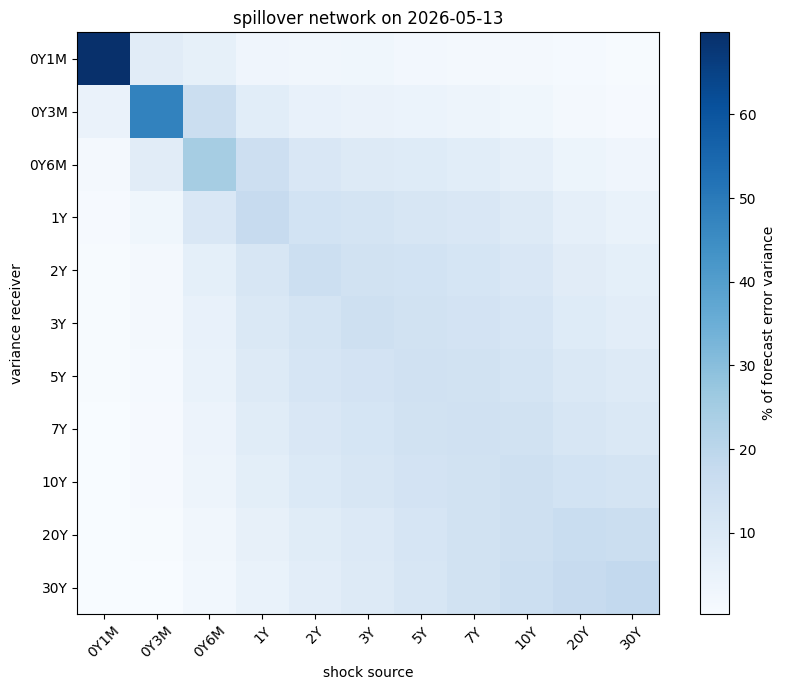

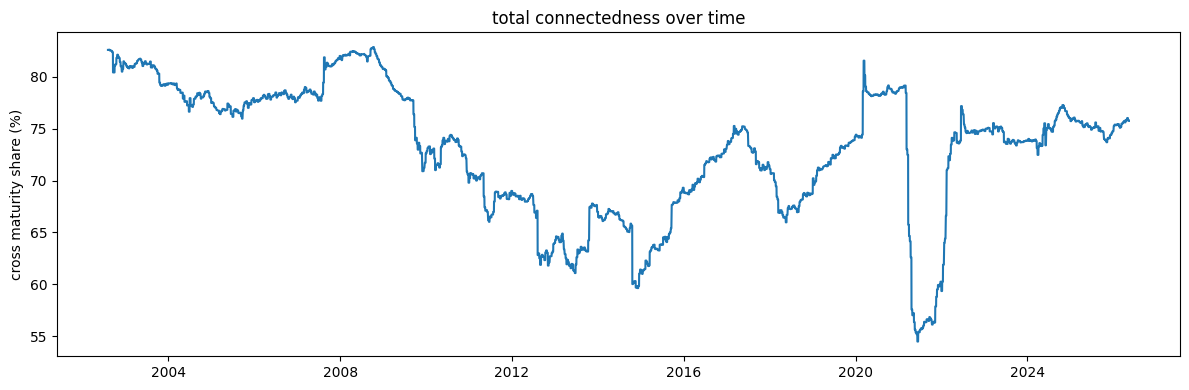

all checks passed, next run final.ipynb


In [6]:
plt.figure(figsize=(9, 7))
plt.imshow(100.0 * lastNetwork, cmap="Blues")
plt.colorbar(label="% of forecast error variance")
plt.xticks(range(len(matList)), matList, rotation=45)
plt.yticks(range(len(matList)), matList)
plt.xlabel("shock source")
plt.ylabel("variance receiver")
plt.title("spillover network on " + str(lastNetworkDate.date()))
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(dailyFeatures.index, dailyFeatures["total_connectedness"])
plt.title("total connectedness over time")
plt.ylabel("cross maturity share (%)")
plt.tight_layout()
plt.show()

#quick sanity checks
assert dailyFeatures.index.is_monotonic_increasing
assert not dailyFeatures.isna().any().any()
for mat in matList:
    calculatedNet = dailyFeatures["to_" + mat] - dailyFeatures["from_" + mat]
    assert np.allclose(calculatedNet, dailyFeatures["net_" + mat])
print("all checks passed, next run final.ipynb")